## Step 1: Data Acquisition and Preparation

In this initial phase, we load the **Mexican Elevation Continuum (CEM 3.0)** at 15 meters and prepare the specific study area to optimize subsequent calculations.

### 1.1 Validation of CEM 15m
The first step is to verify the integrity of the downloaded GeoTIFF file and understand its fundamental geospatial properties:
* **CRS (Coordinate Reference System):** Identify whether the file is in degrees (geographic) or meters (projected).
* **Resolution:** Confirm the pixel size.
* **Bounds:** Validate the geographic extent covered.


File: perote_cem_15m.tif
Resolution (m): (0.00013888453915310135, 0.0001388615140138434)
Coordinate System (CRS): EPSG:4326
Dimensions (px): 4043 x 2394
Bounds: BoundingBox(left=-97.26452472283349, bottom=19.420280018535095, right=-96.7030145310375, top=19.752714483084237)


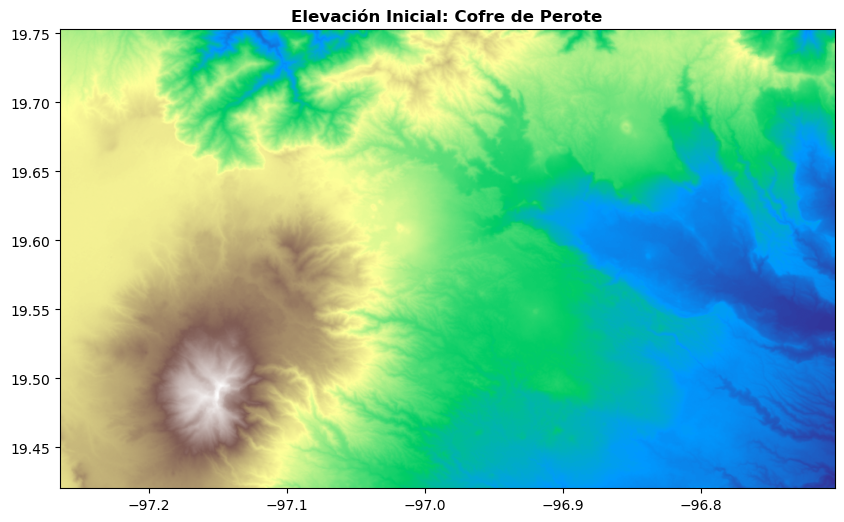

In [7]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import os

# Definir ruta absoluta basada en tu pwd
path_dem = "../data/perote_cem_15m.tif"

# 1. Validar existencia y abrir metadatos
if os.path.exists(path_dem):
    with rasterio.open(path_dem) as src:
        print(f"File: {os.path.basename(path_dem)}")
        print(f"Resolution (m): {src.res}")
        print(f"Coordinate System (CRS): {src.crs}")
        print(f"Dimensions (px): {src.width} x {src.height}")
        print(f"Bounds: {src.bounds}")
        
        # 2. Visualización rápida
        plt.figure(figsize=(10, 6))
        show(src, cmap='terrain', title="Elevación Inicial: Cofre de Perote")
        plt.show()
else:
    print("Error: No se encontró el archivo en la ruta especificada.")

### 1.2 Raster Clipping (Area of Interest)
Since the original file may cover a larger extent than needed, we perform a **clipping** focused on the **Cofre de Perote** and the urban area of **Xalapa**.

**Benefits of clipping:**
1. **Performance:** Reduced RAM usage in matrix processes.
2. **Focus:** Concentrate analysis on areas with the greatest topographic gradient and hydrological relevance.
3. **Storage:** Lighter output files for web visualization.

In [8]:
from rasterio.windows import from_bounds

# Define clip area in geographic coordinates (lon/lat)
# West, South, East, North
bbox = (-97.20, 19.45, -96.90, 19.65) 

with rasterio.open(path_dem) as src:
    # Create the cut window based in the coordinates
    window = from_bounds(*bbox, transform=src.transform)
    
    # read the data from the window
    subset = src.read(1, window=window)
    
    # Update metadata for the new subset
    new_transform = src.window_transform(window)
    new_meta = src.meta.copy()
    new_meta.update({
        "driver": "GTiff",
        "height": subset.shape[0],
        "width": subset.shape[1],
        "transform": new_transform
    })

# Save the clipped raster
output_clip = "../data/perote_clip_15m.tif"
with rasterio.open(output_clip, "w", **new_meta) as dest:
    dest.write(subset, 1)

print(f"Clipped raster saved to: {output_clip}")
print(f"New dimensions: {subset.shape[1]} x {subset.shape[0]}")

Clipped raster saved to: ../data/perote_clip_15m.tif
New dimensions: 2160 x 1440


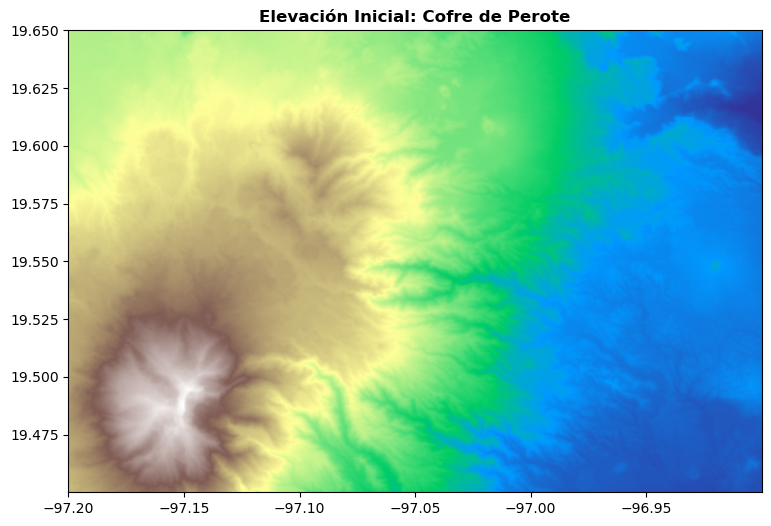

In [9]:
#output_clip = "../data/perote_clip_15m.tif"
with rasterio.open(output_clip) as src_result:
    plt.figure(figsize=(10, 6))
    show(src_result, cmap='terrain', title="Elevación Inicial: Cofre de Perote")
    plt.show()

## Step 2: Raster Engineering & Terrain Derivatives

In this phase, we transform the raw elevation data into morphometric products. This involves reprojecting the data to a planar coordinate system to ensure that horizontal and vertical units are both in meters, allowing for accurate slope and curvature calculations.

### 2.1 Reprojection to UTM
To calculate derivatives like **Slope** and **Aspect**, the raster must be in a Projected Coordinate System (PCS). We will project the clipped DEM from **WGS84** to **UTM Zone 14N (EPSG:32614)**.

In [11]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

input_path = "../data/perote_clip_15m.tif"
output_utm_path = "../data/perote_utm_15m.tif"
dst_crs = 'EPSG:32614' # UTM Zone 14N

with rasterio.open(input_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(output_utm_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear)

### 2.2 Generating Terrain Derivatives
Using the reprojected DEM, we calculate:
* **Slope:** The rate of change of elevation for each pixel (measured in degrees).
* **Aspect:** The compass direction that the terrain slope faces.
* **Hillshade:** A grayscale 3D representation of the surface, used for structural visualization.


Original Min: 1023, Max: 32767


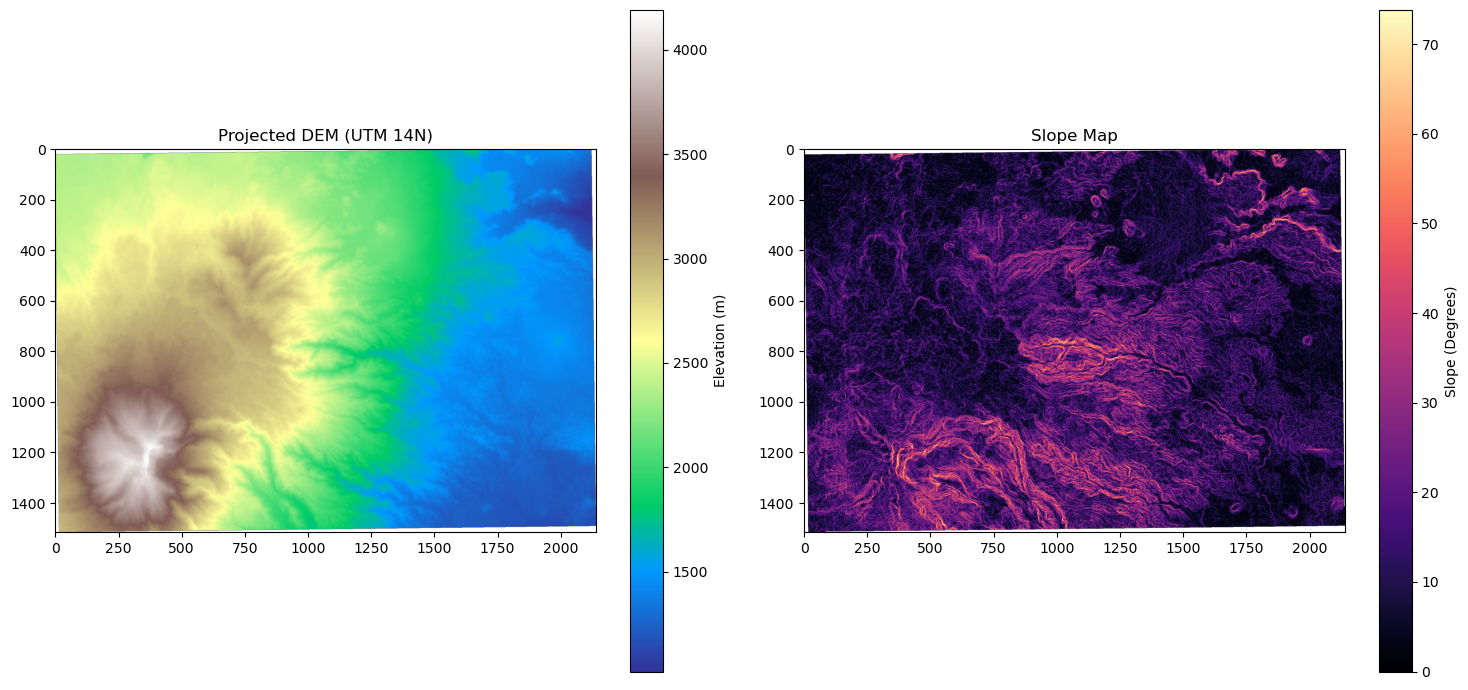

Reprojected DEM saved at: ../data/perote_utm_15m.tif


In [16]:
import numpy as np



with rasterio.open(output_utm_path) as src:

    dem = src.read(1)
    res = src.res[0] # Pixel size in meters

    # 1. Inspect the min/max to find the outlier
    print(f"Original Min: {dem.min()}, Max: {dem.max()}")

    # 2. Mask out extreme values (common in CEM/SRTM)
    # We create a masked array where values outside a logical range are ignored
    dem_clean = np.where((dem < -100) | (dem > 6000), np.nan, dem)

    
    
    # Calculate gradients
    dx, dy = np.gradient(dem_clean, res)
    slope = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi) # Result in degrees

    # 3. Visualization
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    
    # Plot DEM
    im1 = ax[0].imshow(dem_clean, cmap='terrain')
    ax[0].set_title("Projected DEM (UTM 14N)")
    plt.colorbar(im1, ax=ax[0], label="Elevation (m)")
    
    # Plot Slope
    im2 = ax[1].imshow(slope, cmap='magma')
    ax[1].set_title("Slope Map")
    plt.colorbar(im2, ax=ax[1], label="Slope (Degrees)")
    
    plt.tight_layout()
    plt.show()

print(f"Reprojected DEM saved at: {output_utm_path}")